In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 365
dates = pd.date_range(start="2025-01-01", periods=n, freq="D")

products = [
    "Laptop", "Mobile", "Headphones", "Keyboard",
    "Mouse", "Monitor", "Tablet", "Smart Watch",
    "Printer", "Speaker", "Power Bank", "Camera"
]

categories = {
    "Laptop": "Electronics",
    "Mobile": "Electronics",
    "Headphones": "Accessories",
    "Keyboard": "Accessories",
    "Mouse": "Accessories",
    "Monitor": "Electronics",
    "Tablet": "Electronics",
    "Smart Watch": "Electronics",
    "Printer": "Electronics",
    "Speaker": "Electronics",
    "Power Bank": "Accessories",
    "Camera": "Electronics"
}

prices = {
    "Laptop": 55000,
    "Mobile": 25000,
    "Headphones": 2500,
    "Keyboard": 1500,
    "Mouse": 800,
    "Monitor": 12000,
    "Tablet": 18000,
    "Smart Watch": 5000,
    "Printer": 9000,
    "Speaker": 3500,
    "Power Bank": 1800,
    "Camera": 35000
}

product = np.random.choice(products, n)
age = np.random.randint(18, 60, n)
gender = np.random.choice(["Male", "Female"], n)
quantity = np.random.randint(1, 6, n)
discount = np.round(np.random.uniform(0, 0.20, n), 2)

price = [prices[p] for p in product]
category = [categories[p] for p in product]

sales = np.round(
    np.array(quantity) * np.array(price) * (1 - discount), 2
)

df = pd.DataFrame({
    "SRNO": range(1, n + 1),
    "Date": dates,
    "Customer ID": np.random.randint(1001, 1201, n),
    "Age": age,
    "Gender": gender,
    "Product": product,
    "Category": category,
    "Quantity": quantity,
    "Price": price,
    "Discount": discount,
    "Sales": sales
})

print("Dataset created successfully!")
print("Shape:", df.shape)

df.head()

Dataset created successfully!
Shape: (365, 11)


,SRNO,Date,Customer ID,Age,Gender,Product,Category,Quantity,Price,Discount,Sales
0,1,2025-01-01,1099,47,Male,Tablet,Electronics,3,18000,0.04,51840.0
1,2,2025-01-02,1026,46,Male,Keyboard,Accessories,1,1500,0.11,1335.0
2,3,2025-01-03,1008,23,Male,Power Bank,Accessories,5,1800,0.17,7470.0
3,4,2025-01-04,1100,52,Female,Smart Watch,Electronics,4,5000,0.15,17000.0
4,5,2025-01-05,1087,58,Male,Mouse,Accessories,4,800,0.16,2688.0


In [ ]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (365, 11)

Data Types:
SRNO                    int64
Date           datetime64[ns]
Customer ID             int64
Age                     int64
Gender                 object
Product                object
Category               object
Quantity                int64
Price                   int64
Discount              float64
Sales                 float64
dtype: object

Missing Values:
SRNO           0
Date           0
Customer ID    0
Age            0
Gender         0
Product        0
Category       0
Quantity       0
Price          0
Discount       0
Sales          0
dtype: int64

Duplicate Rows:
0


In [ ]:
numeric_cols = ["Age", "Quantity", "Price", "Discount", "Sales"]

print("MEAN")
print(df[numeric_cols].mean())

print("\nMEDIAN")
print(df[numeric_cols].median())

print("\nMODE")
print(df[numeric_cols].mode().iloc[0])

print("\nSTANDARD DEVIATION")
print(df[numeric_cols].std())

MEAN
Age            39.257534
Quantity        2.958904
Price       15804.383562
Discount        0.104329
Sales       41830.819178
dtype: float64

MEDIAN
Age            40.00
Quantity        3.00
Price        9000.00
Discount        0.11
Sales       18000.00
dtype: float64

MODE
Age            29.00
Quantity        3.00
Price       35000.00
Discount        0.14
Sales       31320.00
Name: 0, dtype: float64

STANDARD DEVIATION
Age            11.786306
Quantity        1.426191
Price       17260.075333
Discount        0.059976
Sales       55903.217559
dtype: float64


In [ ]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["Sales"].sum()

print(monthly_sales)

Month
2025-01    1078193.0
2025-02     742060.0
2025-03    1559215.0
2025-04    1268909.0
2025-05    1062564.0
2025-06    1379318.0
2025-07    1371954.0
2025-08    1827794.0
2025-09    1029122.0
2025-10    1377623.0
2025-11    1262526.0
2025-12    1308971.0
Name: Sales, dtype: float64


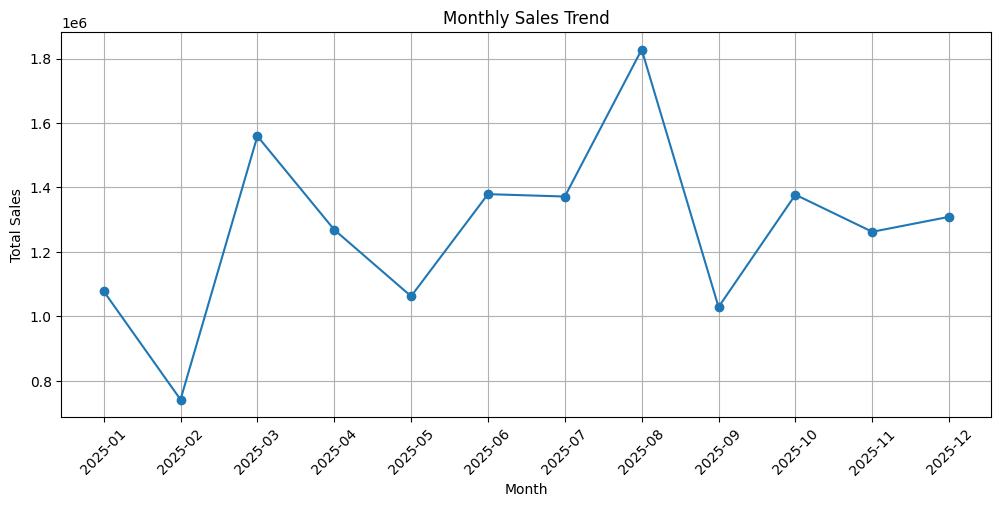

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observation

Monthly sales show variation across the year. Some months generate higher sales than others, indicating changes in sales performance over time.

In [ ]:
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)

quarterly_sales = df.groupby("Quarter")["Sales"].sum()

print(quarterly_sales)

Quarter
2025Q1    3379468.0
2025Q2    3710791.0
2025Q3    4228870.0
2025Q4    3949120.0
Name: Sales, dtype: float64


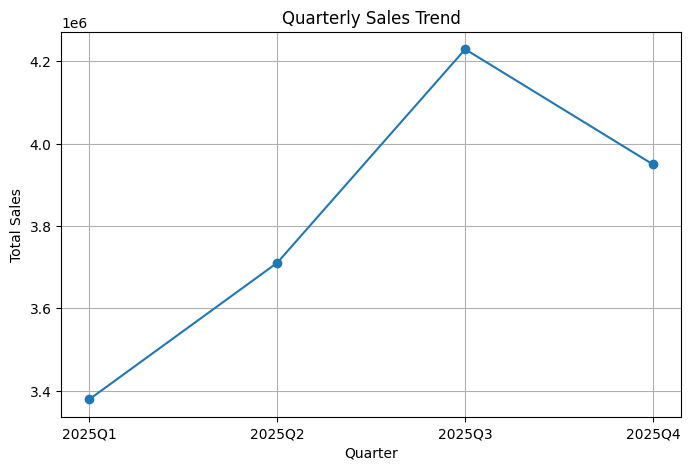

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(quarterly_sales.index, quarterly_sales.values, marker="o")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.grid(True)
plt.show()

### Observation

Quarterly sales show differences in overall performance across the four quarters. This helps identify periods with relatively higher or lower sales.

In [ ]:
bins = [17, 25, 35, 45, 55, 65]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_group = df["Age Group"].value_counts().sort_index()

print(age_group)

Age Group
18-25    60
26-35    80
36-45    98
46-55    96
56-65    31
Name: count, dtype: int64


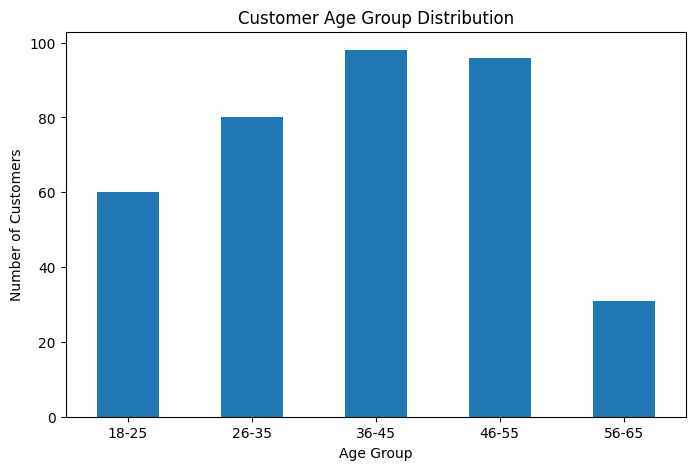

In [ ]:
plt.figure(figsize=(8,5))

age_group.plot(kind="bar")

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.show()

### Observation

The age-group analysis shows the distribution of customers across different age ranges. This helps understand the major customer segments in the dataset.

In [ ]:
gender_counts = df["Gender"].value_counts()

print(gender_counts)

Gender
Male      185
Female    180
Name: count, dtype: int64


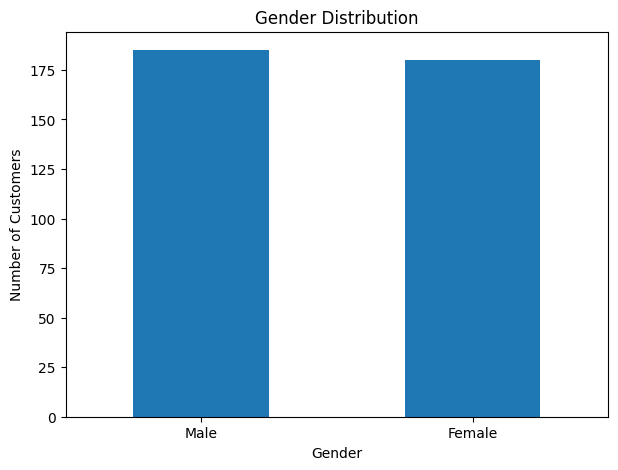

In [ ]:
plt.figure(figsize=(7,5))

gender_counts.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.show()

### Observation

The gender distribution shows the number of male and female customers in the dataset. This provides a basic understanding of the customer profile.

In [ ]:
top_products = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).head(10)

print("Top 10 Best-Selling Products:")
print(top_products)

Top 10 Best-Selling Products:
Product
Camera         121
Laptop         112
Smart Watch    102
Headphones      95
Printer         92
Tablet          89
Mouse           88
Keyboard        85
Mobile          80
Power Bank      77
Name: Quantity, dtype: int64


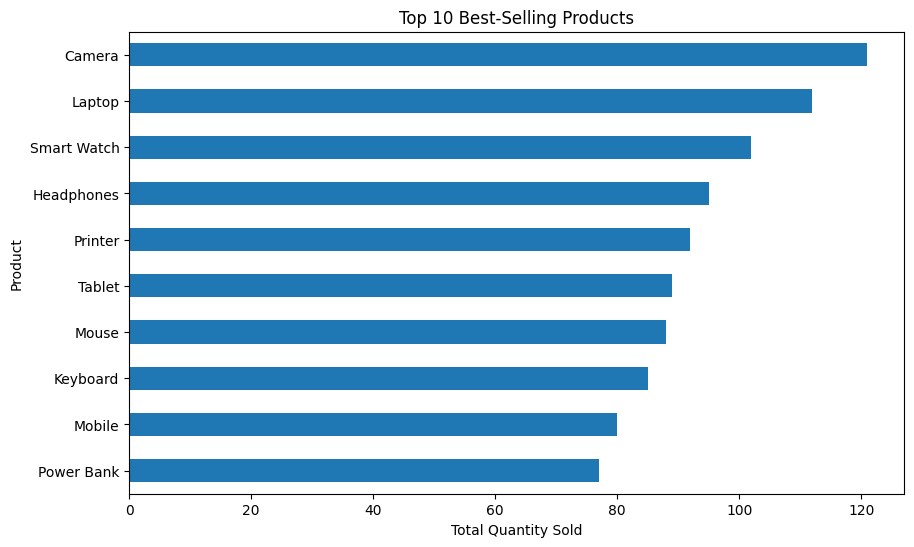

In [ ]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")

plt.show()

### Observation

The top 10 analysis identifies the products with the highest total quantity sold. These products are important for inventory and marketing decisions.

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print("Revenue by Category:")
print(category_sales)

Revenue by Category:
Category
Electronics    14751100.0
Accessories      517149.0
Name: Sales, dtype: float64


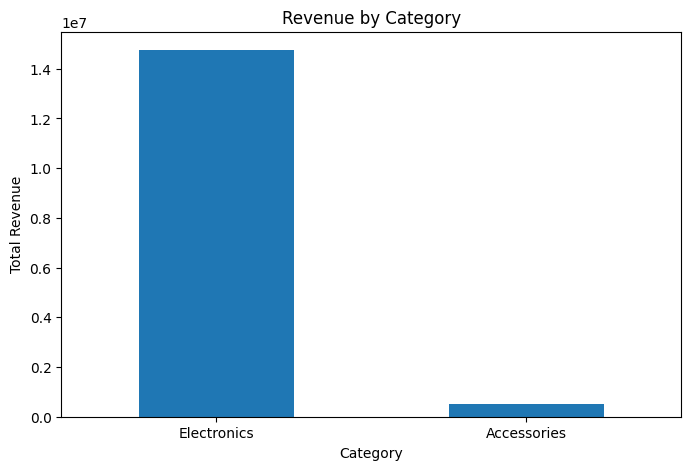

In [ ]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)
plt.show()

### Observation

Revenue varies across product categories. The category generating higher revenue can receive greater attention for inventory planning and marketing activities.

In [ ]:
numeric_cols = ["Age", "Quantity", "Price", "Discount", "Sales"]

corr = df[numeric_cols].corr()

print(corr)

               Age  Quantity     Price  Discount     Sales
Age       1.000000 -0.022576  0.023318 -0.029913  0.009843
Quantity -0.022576  1.000000 -0.004937  0.100686  0.386186
Price     0.023318 -0.004937  1.000000 -0.035498  0.818919
Discount -0.029913  0.100686 -0.035498  1.000000 -0.062731
Sales     0.009843  0.386186  0.818919 -0.062731  1.000000


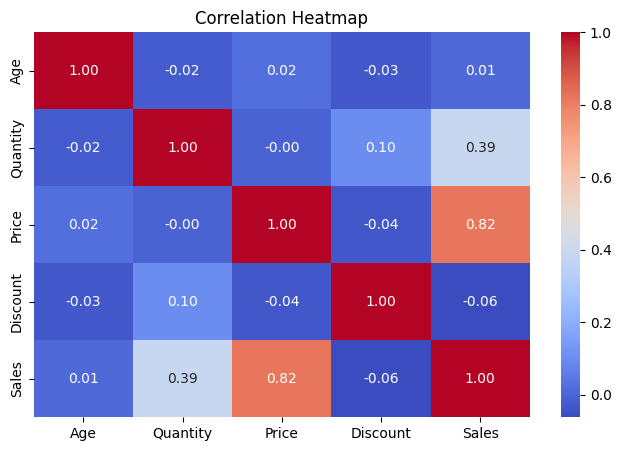

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap shows the relationships between numerical variables such as age, quantity, price, discount, and sales. Higher correlation values indicate stronger relationships between variables.

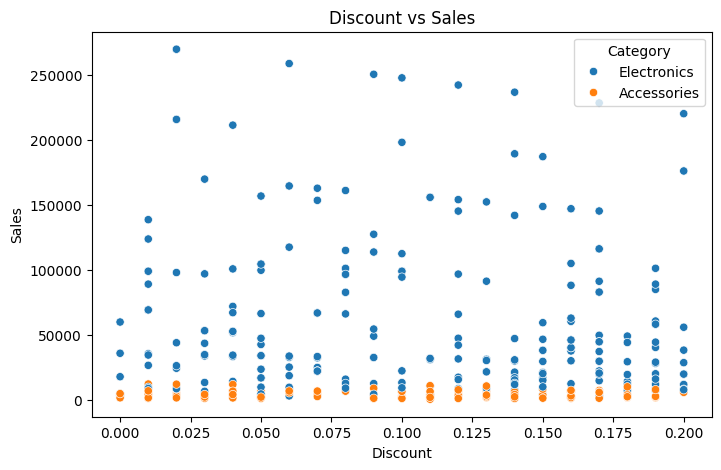

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Sales",
    hue="Category"
)

plt.title("Discount vs Sales")
plt.xlabel("Discount")
plt.ylabel("Sales")

plt.show()

### Observation

The scatter plot shows the relationship between discount and sales. The distribution of points helps understand how sales values vary at different discount levels.

# Conclusion

The Retail Sales dataset was analyzed using Python, Pandas, Matplotlib, and Seaborn. The analysis included data inspection, descriptive statistics, monthly and quarterly sales trends, customer demographics, product performance, category revenue, correlation analysis, and discount versus sales analysis.

## Key Findings

- Sales performance varies across different months and quarters.
- Customer age groups and gender distribution provide useful demographic information.
- The top-selling products can be identified based on quantity sold.
- Revenue differs across product categories.
- Correlation analysis helps understand relationships between numerical variables.
- The discount versus sales analysis provides additional insights into sales patterns.

## Business Recommendations

1. Focus inventory and marketing efforts on high-selling products.
2. Use customer demographic information for targeted marketing campaigns.
3. Monitor discounts carefully and analyze their relationship with sales before offering large discounts.
4. Use monthly and quarterly sales trends for better sales and inventory planning.

In [ ]:
df.to_csv("retail_sales.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!
